<a href="https://colab.research.google.com/github/jeeva477/Deep-Learning/blob/main/cnn_using_cifar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3334s 20us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 51s 39ms/step - accuracy: 0.3289 - loss: 1.8040 - val_accuracy: 0.4985 - val_loss: 1.4463
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 37ms/step - accuracy: 0.4472 - loss: 1.5183 - val_accuracy: 0.5405 - val_loss: 1.2761
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 50s 40ms/step - accuracy: 0.5009 - loss: 1.3802 - val_accuracy: 0.5871 - val_loss: 1.1610
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.5312 - loss: 1.2976 - val_accuracy: 0.6061 - val_loss: 1.1144
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 47s 38ms/step - accuracy: 0.5572 - loss: 1.2374 - val_accuracy: 0.6286 - val_loss: 1.0621
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6298 - loss: 1.0598
Accuracy: 0.629800021648407
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Image 1
Actual    : Cat
Predicted : Cat
------------------------------


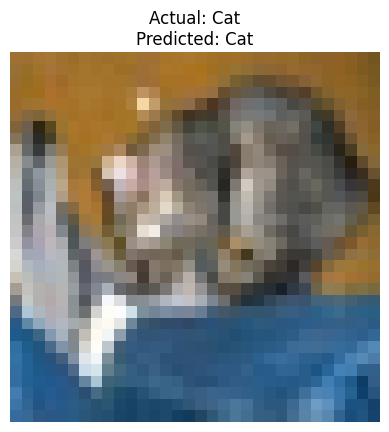

Image 2
Actual    : Ship
Predicted : Ship
------------------------------


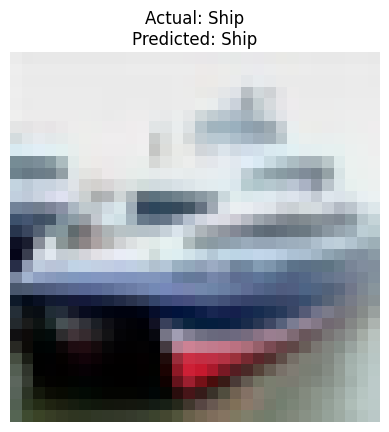

Image 3
Actual    : Ship
Predicted : Ship
------------------------------


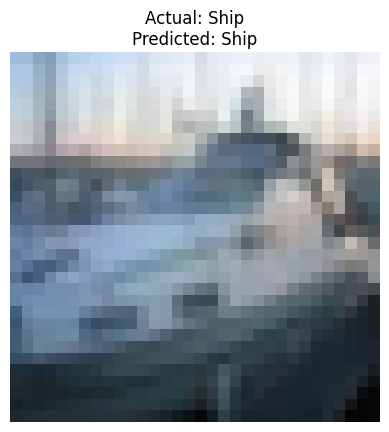

Image 4
Actual    : Airplane
Predicted : Airplane
------------------------------


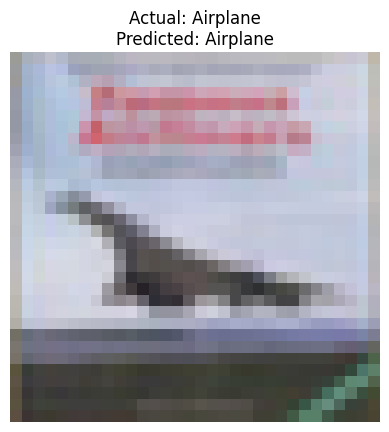

Image 5
Actual    : Frog
Predicted : Frog
------------------------------


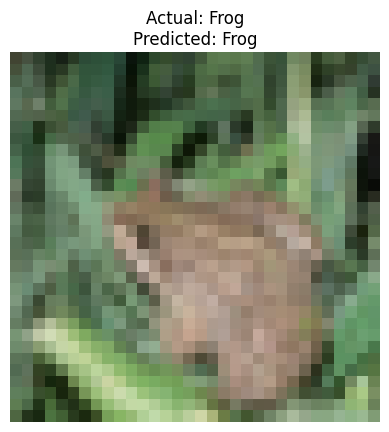

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

classes = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

X_train = X_train / 255.0
X_test = X_test / 255.0

model = Sequential()

model.add(Input(shape=(32, 32, 3)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu')
)
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

# Predict top 5 images

predictions = model.predict(X_test[:5])

for i in range(5):

    predicted_label = np.argmax(predictions[i])

    actual_label = y_test[i][0]

    print(f"Image {i+1}")
    print(f"Actual    : {classes[actual_label]}")
    print(f"Predicted : {classes[predicted_label]}")
    print("-" * 30)

    plt.imshow(X_test[i])
    plt.title(
        f"Actual: {classes[actual_label]}\n"
        f"Predicted: {classes[predicted_label]}"
    )
    plt.axis('off')
    plt.show()



